In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [4]:
train_df = pd.read_csv('../data/train.csv')
test_df = pd.read_csv('../data/test.csv')

print(f'Train Data Shape: {train_df.shape}')
print(f'Test Data Shape: {test_df.shape}')

Train Data Shape: (594194, 21)
Test Data Shape: (254655, 20)


# Exploratory Data Analysis (EDA)

EDA, modellemeye geçmeden önce verimizi tanımak için yapılır. Amacımız:
- Verinin genel yapısını anlamak
- Eksik/hatalı değerleri tespit etmek
- Değişkenlerin dağılımlarını görmek
- Hedef değişken (Churn) ile ilişkileri keşfetmek

## 1. Genel Bakış

In [5]:
# Veri tipleri ve genel bilgi
print("=" * 50)
print("TRAIN VERİSİ - GENEL BİLGİ")
print("=" * 50)
train_df.info()

print("\n" + "=" * 50)
print("İLK 5 SATIR")
print("=" * 50)
train_df.head()

TRAIN VERİSİ - GENEL BİLGİ
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [6]:
# Eksik değer analizi
print("=" * 50)
print("EKSİK DEĞER ANALİZİ")
print("=" * 50)

missing = train_df.isnull().sum()
missing_pct = (missing / len(train_df)) * 100
missing_df = pd.DataFrame({'Eksik Sayı': missing, 'Eksik %': missing_pct})
missing_df = missing_df[missing_df['Eksik Sayı'] > 0].sort_values('Eksik %', ascending=False)

if missing_df.empty:
    print("Hiç eksik değer yok!")
else:
    print(missing_df)

# Duplicate kontrolü
duplicates = train_df.duplicated().sum()
print(f"\nToplam duplicate satır: {duplicates}")

EKSİK DEĞER ANALİZİ
Hiç eksik değer yok!

Toplam duplicate satır: 0


In [7]:
# Numerik sütunların istatistikleri
print("=" * 50)
print("NUMERİK DEĞİŞKENLER - İSTATİSTİKLER")
print("=" * 50)
train_df.describe().T

NUMERİK DEĞİŞKENLER - İSTATİSTİKLER


,count,mean,std,min,25%,50%,75%,max
id,594194.0,297096.500000,171529.177262,0.00,148548.25,297096.50,445644.75,594193.00
SeniorCitizen,594194.0,0.114102,0.317936,0.00,0.00,0.00,0.00,1.00
tenure,594194.0,36.577258,25.061922,1.00,12.00,35.00,62.00,72.00
MonthlyCharges,594194.0,65.866223,31.067444,18.25,29.90,74.10,90.80,118.75
TotalCharges,594194.0,2494.377057,2353.916710,18.80,639.65,1433.65,4263.80,8684.80


## 2. Target Distribution (Hedef Değişken Dağılımı)

**Churn** nedir? Bir müşterinin hizmeti bırakıp bırakmadığını gösterir (Yes = ayrıldı, No = kaldı).

**Neden önemli?** Eğer veri dengesizse (örn. %95 No, %5 Yes), model her şeyi "No" tahmin ederek yüksek accuracy elde edebilir ama pratikte işe yaramaz. Bu yüzden class imbalance'ı erkenden tespit etmek gerekir.

Churn Dağılımı:
         Sayı  Oran (%)
Churn                  
No     460377     77.48
Yes    133817     22.52


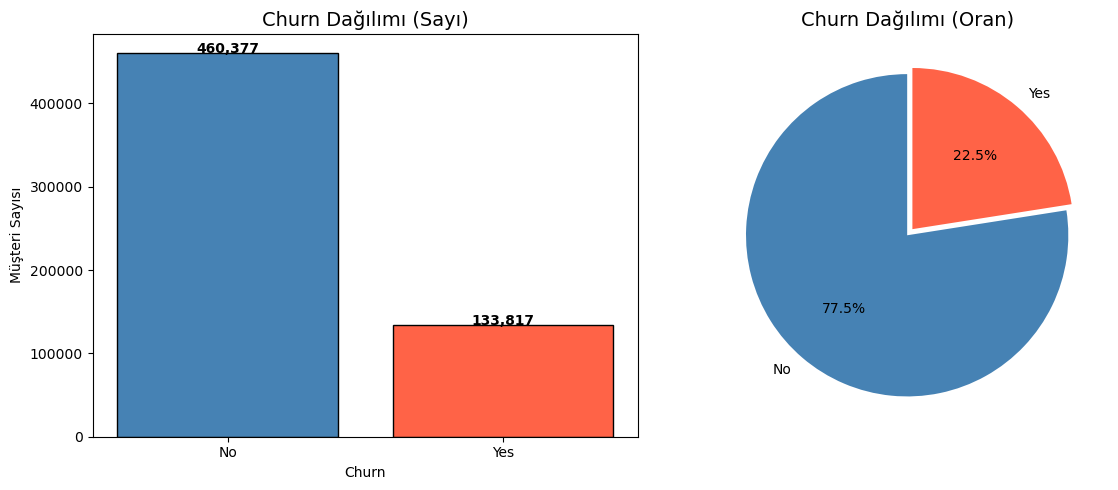

In [8]:
churn_counts = train_df['Churn'].value_counts()
churn_pct = train_df['Churn'].value_counts(normalize=True) * 100

print("Churn Dağılımı:")
print(pd.DataFrame({'Sayı': churn_counts, 'Oran (%)': churn_pct.round(2)}))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar plot
axes[0].bar(churn_counts.index, churn_counts.values, color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Churn Dağılımı (Sayı)', fontsize=14)
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Müşteri Sayısı')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(churn_counts.values, labels=churn_counts.index, autopct='%1.1f%%',
            colors=['steelblue', 'tomato'], startangle=90, explode=(0, 0.05))
axes[1].set_title('Churn Dağılımı (Oran)', fontsize=14)

plt.tight_layout()
plt.show()

## 3. Numerik Değişkenler Analizi

Bu veri setindeki numerik değişkenler: **tenure** (kaç aydır müşteri), **MonthlyCharges** (aylık ücret), **TotalCharges** (toplam ödenen tutar).

**Histogram:** Her değerin kaç kez geçtiğini gösterir — dağılımın şeklini (normal mi, çarpık mı?) anlarız.  
**KDE (Kernel Density Estimate):** Histogramın yumuşatılmış versiyonu.  
**Churn=Yes vs No karşılaştırması:** Hangi değer aralığında müşterilerin daha çok ayrıldığını görmek için ikisini üst üste çizeriz.

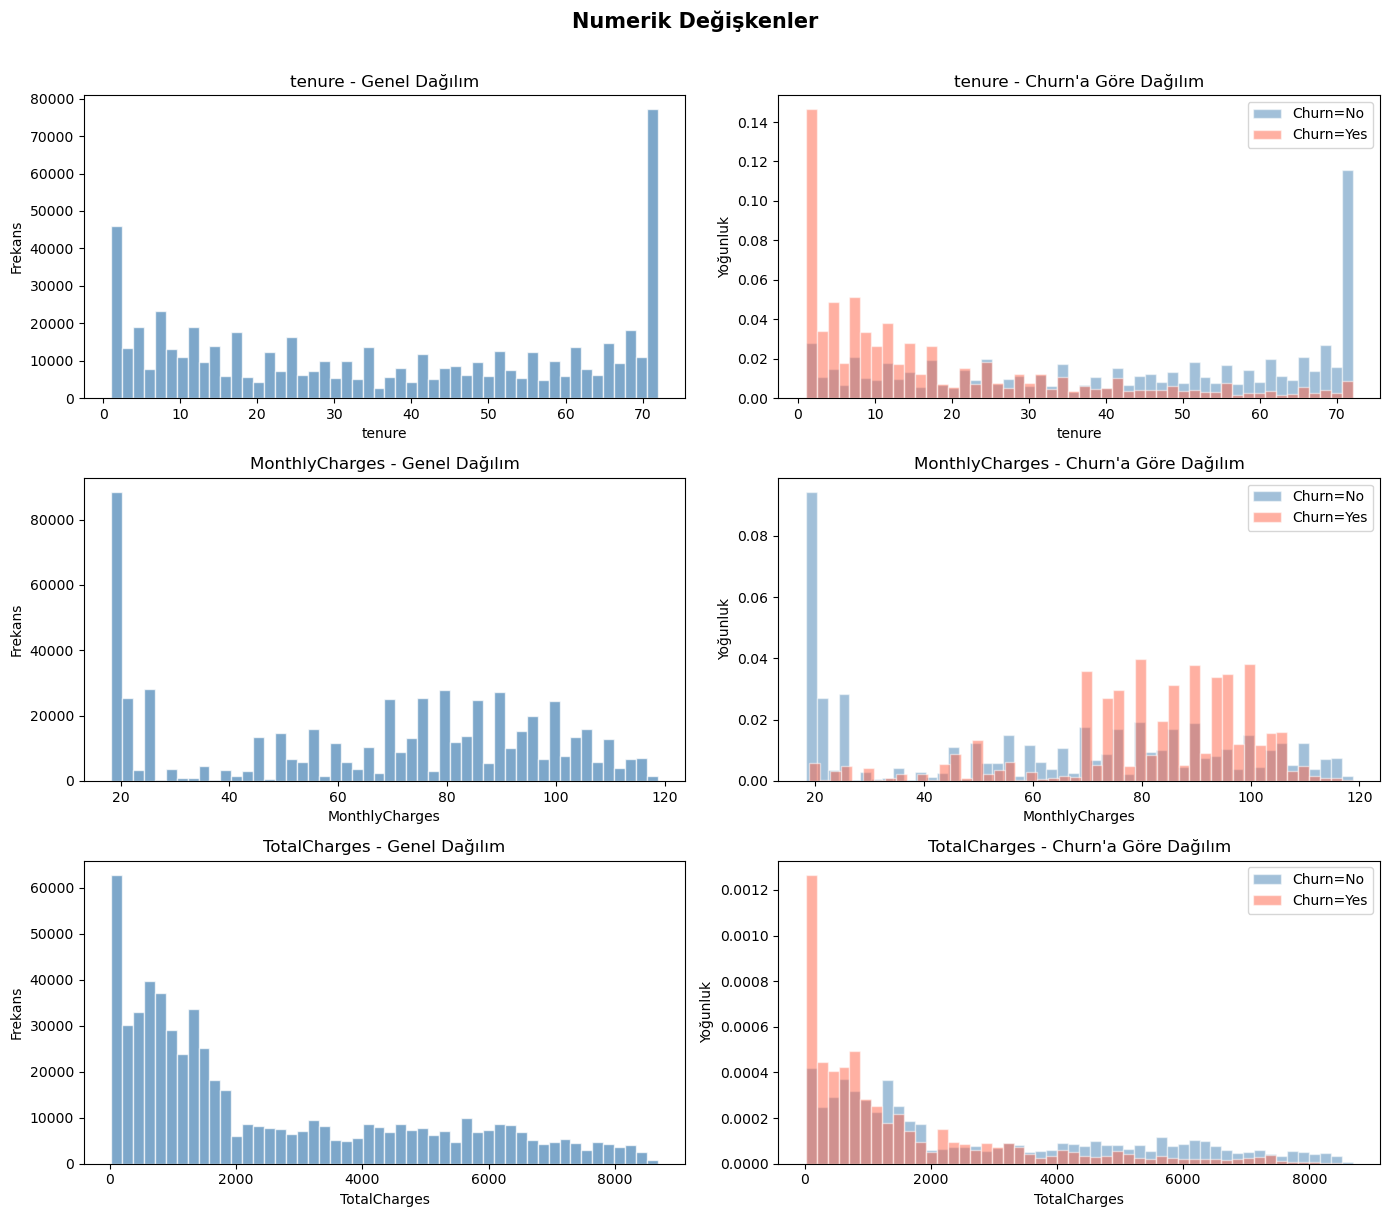


Churn'a Göre Ortalama Değerler:


,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,42.23,61.29,2771.50
Yes,17.13,81.60,1540.98


In [9]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(len(numeric_cols), 2, figsize=(14, 12))

for i, col in enumerate(numeric_cols):
    # Sol: Genel dağılım (KDE + Histogram)
    axes[i, 0].hist(train_df[col].dropna(), bins=50, color='steelblue', edgecolor='white', alpha=0.7)
    axes[i, 0].set_title(f'{col} - Genel Dağılım', fontsize=12)
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Frekans')

    # Sağ: Churn=Yes vs No karşılaştırması
    for label, color in zip(['No', 'Yes'], ['steelblue', 'tomato']):
        subset = train_df[train_df['Churn'] == label][col].dropna()
        axes[i, 1].hist(subset, bins=50, alpha=0.5, color=color, label=f'Churn={label}', density=True, edgecolor='white')
    axes[i, 1].set_title(f'{col} - Churn\'a Göre Dağılım', fontsize=12)
    axes[i, 1].set_xlabel(col)
    axes[i, 1].set_ylabel('Yoğunluk')
    axes[i, 1].legend()

plt.suptitle('Numerik Değişkenler', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Özet istatistikler churn'e göre
print("\nChurn'a Göre Ortalama Değerler:")
train_df.groupby('Churn')[numeric_cols].mean().round(2)

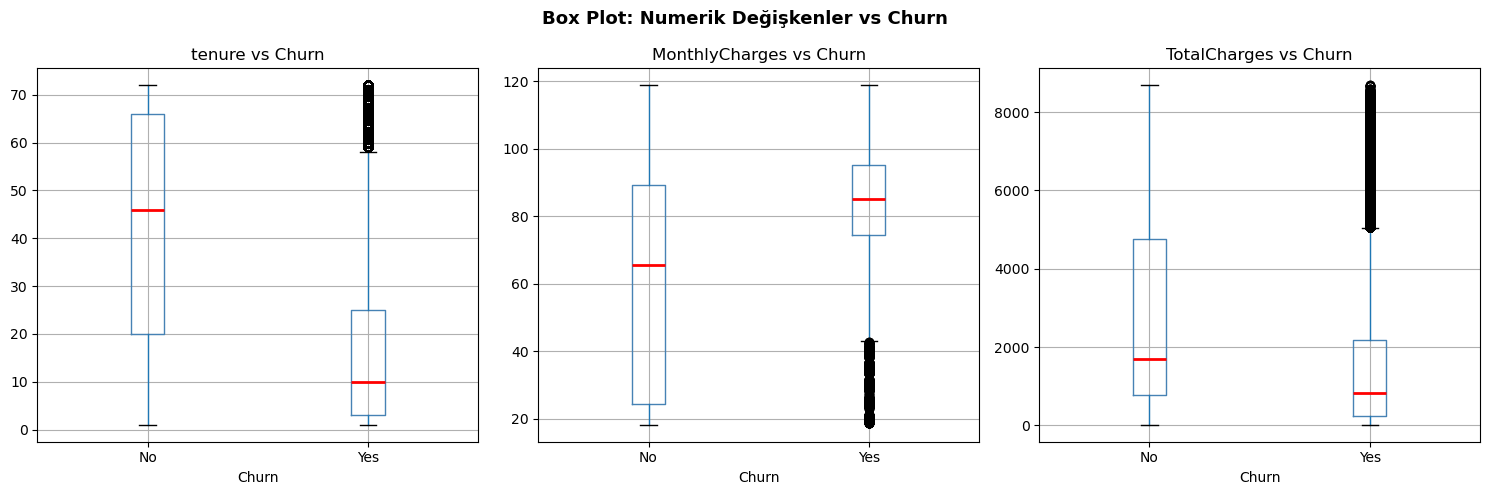

In [10]:
# Box plot - outlier tespiti için
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(numeric_cols):
    train_df.boxplot(column=col, by='Churn', ax=axes[i], 
                     boxprops=dict(color='steelblue'),
                     medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(f'{col} vs Churn', fontsize=12)
    axes[i].set_xlabel('Churn')

plt.suptitle('Box Plot: Numerik Değişkenler vs Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Kategorik Değişkenler Analizi

Kategorik değişkenler için en önemli soru: **"Bu kategoriye giren müşterilerin churn oranı ne kadar?"**

**Count plot:** Kaç müşteri hangi kategoride?  
**Churn oranı bar plot:** Her kategorideki churn yüzdesi — en bilgi verici grafik bu.

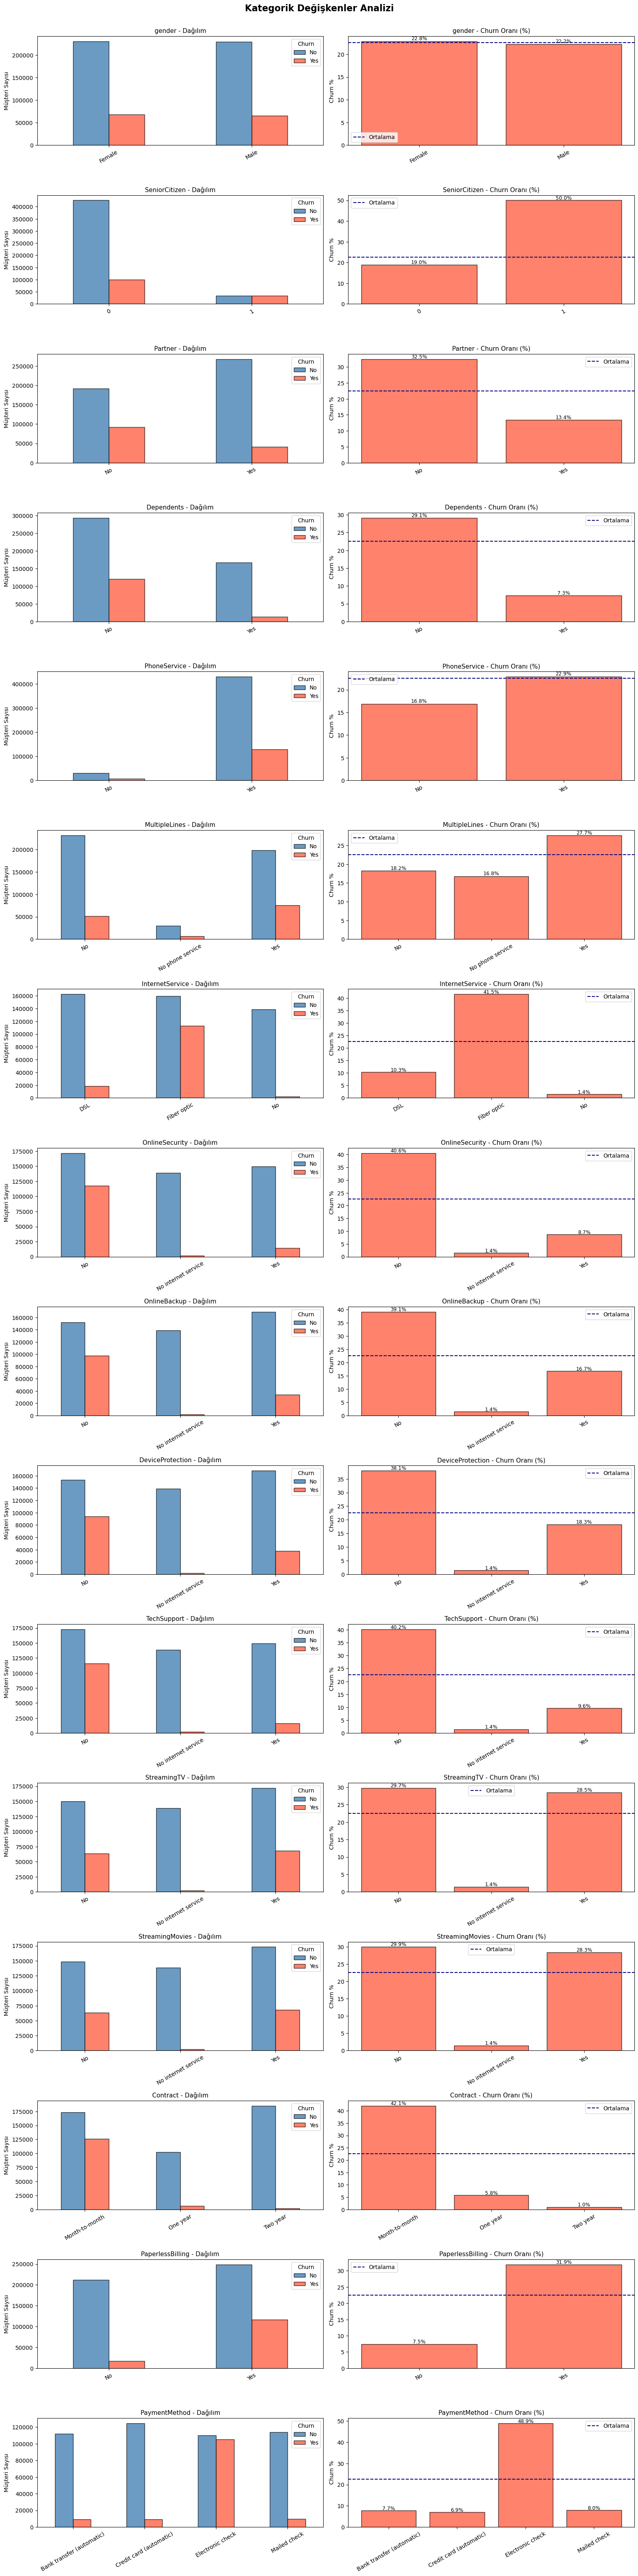

In [11]:
categorical_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
                    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                    'Contract', 'PaperlessBilling', 'PaymentMethod']

n_cols = 2
n_rows = len(categorical_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))

for i, col in enumerate(categorical_cols):
    # Sol: Sayısal dağılım (Churn'e göre renklendirilmiş)
    churn_counts_cat = train_df.groupby([col, 'Churn']).size().unstack(fill_value=0)
    churn_counts_cat.plot(kind='bar', ax=axes[i, 0], color=['steelblue', 'tomato'],
                          edgecolor='black', alpha=0.8)
    axes[i, 0].set_title(f'{col} - Dağılım', fontsize=11)
    axes[i, 0].set_xlabel('')
    axes[i, 0].set_ylabel('Müşteri Sayısı')
    axes[i, 0].tick_params(axis='x', rotation=30)
    axes[i, 0].legend(title='Churn')

    # Sağ: Churn oranı (%)
    churn_rate = train_df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
    bars = axes[i, 1].bar(churn_rate.index.astype(str), churn_rate.values,
                           color='tomato', edgecolor='black', alpha=0.8)
    axes[i, 1].set_title(f'{col} - Churn Oranı (%)', fontsize=11)
    axes[i, 1].set_xlabel('')
    axes[i, 1].set_ylabel('Churn %')
    axes[i, 1].tick_params(axis='x', rotation=30)
    axes[i, 1].axhline(y=train_df['Churn'].eq('Yes').mean() * 100,
                        color='navy', linestyle='--', linewidth=1.5, label='Ortalama')
    axes[i, 1].legend()
    for bar, val in zip(bars, churn_rate.values):
        axes[i, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                         f'{val:.1f}%', ha='center', fontsize=9)

plt.suptitle('Kategorik Değişkenler Analizi', fontsize=16, fontweight='bold', y=1.001)
plt.tight_layout()
plt.show()

## 5. Korelasyon Analizi

**Korelasyon nedir?** İki değişkenin birlikte nasıl değiştiğini ölçer (-1 ile +1 arası).  
- **+1:** Biri artarken diğeri de artar  
- **-1:** Biri artarken diğeri azalır  
- **0:** İlişki yok  

**Heatmap'i neden kullanırız?** Tüm değişkenler arası ilişkileri tek bir görsel ile görmek için. Özellikle birbirine çok benzer (yüksek korelasyonlu) değişkenleri tespit etmek önemli — bunlar modeli olumsuz etkileyebilir (multicollinearity).

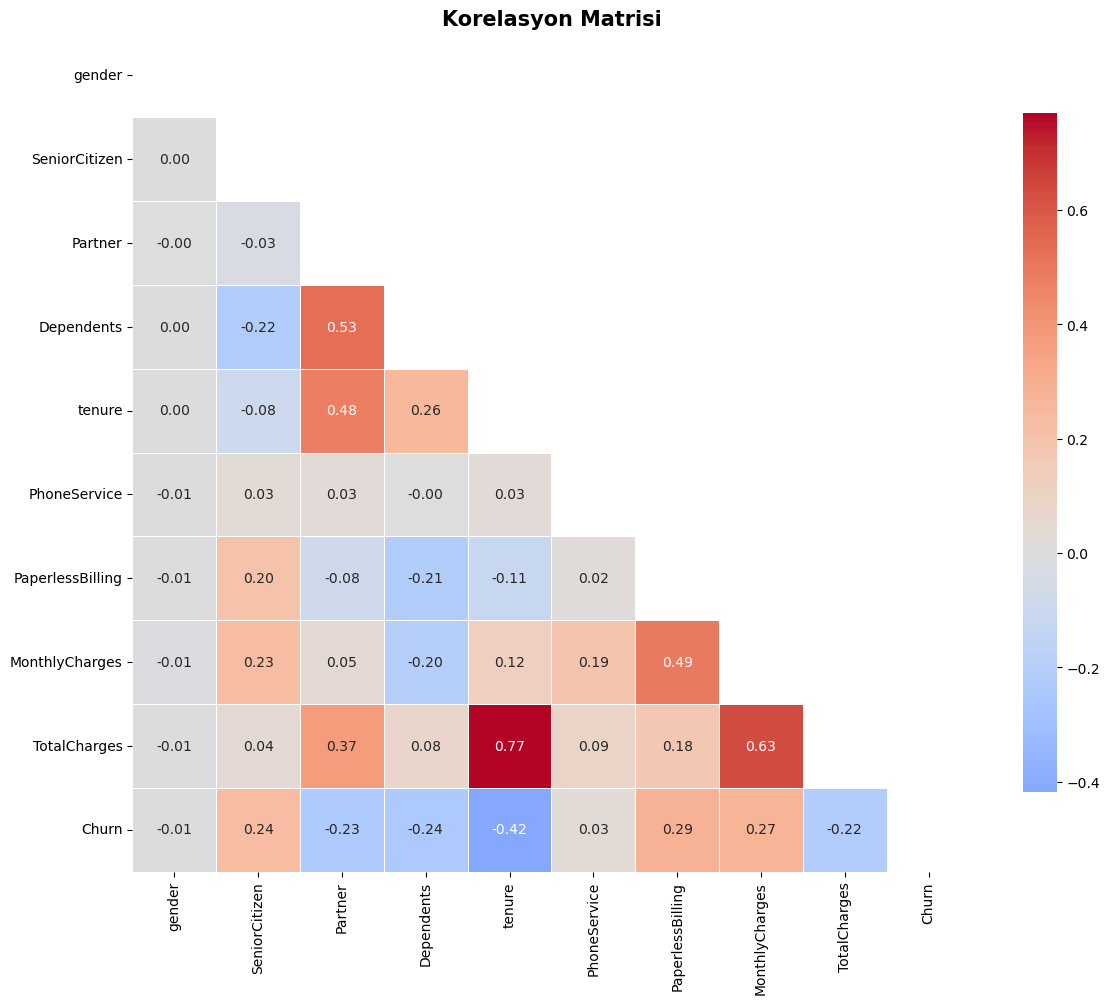


Churn ile Korelasyon (mutlak değere göre sıralı):
tenure              0.418
PaperlessBilling    0.285
MonthlyCharges      0.273
Dependents          0.240
SeniorCitizen       0.236
Partner             0.228
TotalCharges        0.218
PhoneService        0.035
gender              0.007
Name: Churn, dtype: float64


In [12]:
# Korelasyon için önce tüm değişkenleri sayısallaştıralım
corr_df = train_df.copy()
corr_df['Churn_binary'] = (corr_df['Churn'] == 'Yes').astype(int)

# Binary / Yes-No sütunlarını 0/1 yap
binary_map = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}
for col in corr_df.select_dtypes('object').columns:
    if corr_df[col].nunique() == 2:
        corr_df[col] = corr_df[col].map(binary_map)

# Sadece sayısal sütunları al
num_corr = corr_df.select_dtypes(include=[np.number]).drop(columns=['id', 'Churn_binary'], errors='ignore')
num_corr['Churn'] = corr_df['Churn_binary']

corr_matrix = num_corr.corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Üst üçgeni maskele
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Korelasyon Matrisi', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Churn ile en yüksek korelasyonlu değişkenler
print("\nChurn ile Korelasyon (mutlak değere göre sıralı):")
churn_corr = corr_matrix['Churn'].drop('Churn').abs().sort_values(ascending=False)
print(churn_corr.round(3))

## EDA Özeti ve Çıkarımlar

Grafikleri çalıştırdıktan sonra şunları bekleyebilirsin:

**Tenure (Müşteri süresi):**
- Kısa süreli müşteriler (1-12 ay) çok daha yüksek churn oranına sahip
- Uzun süreli müşteriler sadık — bunu "early churn risk" olarak değerlendiririz

**MonthlyCharges (Aylık ücret):**
- Yüksek aylık ücret ödeyen müşteriler daha çok ayrılıyor
- Mantıklı: Pahalı hizmet → memnuniyetsizlik riski artar

**Contract (Sözleşme tipi):**
- Month-to-month müşteriler çok daha yüksek churn — bağlılıkları az
- One/Two year sözleşmeliler neredeyse hiç ayrılmıyor

**InternetService:**
- Fiber optik müşterileri DSL'den daha fazla ayrılıyor (muhtemelen daha pahalı)

Bu bulgular Feature Engineering'de yeni değişkenler yaratmamıza rehberlik edecek.

# Feature Engineering

**Feature Engineering nedir?** Ham veriden modelin daha iyi öğrenmesi için yeni, anlamlı değişkenler türetmektir.

EDA'dan çıkardığımız bulgulara göre şu yeni değişkenleri oluşturacağız:

1. **tenure_group** — Kısa/orta/uzun süreli müşteri grupları
2. **ChargesPerMonth_ratio** — TotalCharges / tenure (aylık ortalama)
3. **num_services** — Kaç adet servis kullandığı (toplam hizmet sayısı)
4. **has_online_services** — Online güvenlik/backup/tech support var mı?
5. **is_high_risk** — Month-to-month sözleşme + yüksek ücret kombinasyonu
6. **TotalCharges_missing** — TotalCharges eksikse flag (bazı veri setlerinde olur)

Ardından tüm kategorik değişkenleri encode edip modele hazır hale getireceğiz.

In [13]:
def feature_engineering(df):
    df = df.copy()

    # --- 1. TotalCharges: bazı satırlarda boşluk string olabilir, float'a çevir ---
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    df['TotalCharges_missing'] = df['TotalCharges'].isnull().astype(int)
    # Eksik TotalCharges → tenure * MonthlyCharges ile doldur (mantıklı bir imputation)
    df['TotalCharges'] = df['TotalCharges'].fillna(df['tenure'] * df['MonthlyCharges'])

    # --- 2. Tenure group ---
    # EDA'da kısa süreli müşterilerin daha çok ayrıldığını gördük
    df['tenure_group'] = pd.cut(df['tenure'],
                                 bins=[0, 12, 24, 48, 72],
                                 labels=['0-12', '13-24', '25-48', '49-72'])

    # --- 3. Charges per month ratio ---
    # TotalCharges / tenure → aylık ortalama ne kadar ödemiş
    # tenure=0 olan satırlar için 0 koyuyoruz
    df['avg_monthly_charges'] = np.where(
        df['tenure'] > 0,
        df['TotalCharges'] / df['tenure'],
        df['MonthlyCharges']
    )

    # --- 4. Hizmet sayısı ---
    # Kaç adet ek hizmet kullandığı — daha fazla hizmet = daha bağlı müşteri
    service_cols = ['PhoneService', 'MultipleLines', 'InternetService',
                    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                    'TechSupport', 'StreamingTV', 'StreamingMovies']
    df['num_services'] = sum(
        (df[col] == 'Yes').astype(int) for col in service_cols
    )

    # --- 5. Online koruma servisleri (güvenlik + backup + tech support) ---
    online_protect = ['OnlineSecurity', 'OnlineBackup', 'TechSupport']
    df['has_online_protection'] = (
        (df[online_protect] == 'Yes').sum(axis=1) > 0
    ).astype(int)

    # --- 6. Yüksek risk flag ---
    # Month-to-month + yüksek aylık ücret = en çok churn olan segment
    monthly_median = df['MonthlyCharges'].median()
    df['is_high_risk'] = (
        (df['Contract'] == 'Month-to-month') &
        (df['MonthlyCharges'] > monthly_median)
    ).astype(int)

    # --- 7. Streaming hizmetleri ---
    df['has_streaming'] = (
        ((df['StreamingTV'] == 'Yes') | (df['StreamingMovies'] == 'Yes'))
    ).astype(int)

    return df

train_df = feature_engineering(train_df)
test_df  = feature_engineering(test_df)

print("Yeni sütunlar eklendi:")
new_cols = ['TotalCharges_missing', 'tenure_group', 'avg_monthly_charges',
            'num_services', 'has_online_protection', 'is_high_risk', 'has_streaming']
print(train_df[new_cols].head(10))

Yeni sütunlar eklendi:
   TotalCharges_missing tenure_group  avg_monthly_charges  num_services  \
0                     0        25-48            57.029310             4   
1                     0        49-72            65.141379             5   
2                     0        49-72           100.712931             5   
3                     0         0-12            70.700000             1   
4                     0         0-12            70.450000             1   
5                     0         0-12            20.200000             1   
6                     0        13-24            22.233333             1   
7                     0        49-72            94.826389             8   
8                     0         0-12            79.550000             3   
9                     0        49-72            86.150909             5   

   has_online_protection  is_high_risk  has_streaming  
0                      1             0              0  
1                      1             0 

## Encoding & Preprocessing

Modeller sayısal veri ister. Kategorik değişkenleri sayıya çevirmek için:

- **Label Encoding (binary):** 2 sınıflı değişkenler için (Yes/No → 1/0)
- **One-Hot Encoding:** 2'den fazla sınıflı değişkenler için (Contract: Month-to-month, One year, Two year → 3 ayrı sütun)

`drop_first=True` ile dummy variable trap'i önleriz (k kategorinin k-1 sütunla temsil edilmesi yeterli).

In [16]:
from sklearn.preprocessing import LabelEncoder

def encode_df(df):
    df = df.copy()

    # tenure_group Categorical dtype → önce string'e çevir
    if 'tenure_group' in df.columns:
        df['tenure_group'] = df['tenure_group'].astype(str)
        tenure_map = {'0-12': 0, '13-24': 1, '25-48': 2, '49-72': 3}
        df['tenure_group'] = df['tenure_group'].map(tenure_map).fillna(-1).astype(int)

    # Binary encode (2 sınıflı: Yes/No, Male/Female)
    binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
    binary_map = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}
    for col in binary_cols:
        if col in df.columns:
            df[col] = df[col].map(binary_map)

    # MultipleLines, OnlineSecurity vb. → 'No phone/internet service' değerlerini 'No' yap
    no_service_cols = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
    for col in no_service_cols:
        if col in df.columns:
            df[col] = df[col].replace({'No phone service': 'No', 'No internet service': 'No'})
            df[col] = df[col].map({'Yes': 1, 'No': 0})

    # One-hot encode (çok sınıflı)
    ohe_cols = [c for c in ['InternetService', 'Contract', 'PaymentMethod'] if c in df.columns]
    df = pd.get_dummies(df, columns=ohe_cols, drop_first=True)

    return df

train_enc = encode_df(train_df)
test_enc  = encode_df(test_df)

# Target encode
train_enc['Churn'] = (train_enc['Churn'] == 'Yes').astype(int)

print(f"Train shape: {train_enc.shape}")
print(f"Test shape:  {test_enc.shape}")
print("\nSütunlar:")
print(list(train_enc.columns))

Train shape: (594194, 32)
Test shape:  (254655, 31)

Sütunlar:
['id', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'TotalCharges_missing', 'tenure_group', 'avg_monthly_charges', 'num_services', 'has_online_protection', 'is_high_risk', 'has_streaming', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [17]:
# Train/test split için feature listesini hazırla
# id ve Churn dışındaki tüm sütunlar feature
drop_cols = ['id', 'Churn']
feature_cols = [c for c in train_enc.columns if c not in drop_cols]

# Test setinde olmayan sütunları sıfırla, sıraları eşleştir
for col in feature_cols:
    if col not in test_enc.columns:
        test_enc[col] = 0

X = train_enc[feature_cols]
y = train_enc['Churn']
X_test_final = test_enc[feature_cols]

print(f"Feature sayısı: {len(feature_cols)}")
print(f"X shape: {X.shape}")
print(f"y dağılımı:\n{y.value_counts()}")

Feature sayısı: 30
X shape: (594194, 30)
y dağılımı:
Churn
0    460377
1    133817
Name: count, dtype: int64


# Modelling

**Strateji:** Birden fazla model deneriz, cross-validation ile karşılaştırırız, en iyi modeli seçeriz.

**Neden cross-validation?**  
Tek bir train/val split şansa göre iyi veya kötü sonuç verebilir. CV, veriyi K parçaya böler; her seferinde 1 parçayı validation, K-1 parçayı train olarak kullanır. K sonucun ortalaması çok daha güvenilirdir.

**Metrik: ROC-AUC**  
Churn veri setlerinde class imbalance olduğu için accuracy yanıltıcı olabilir.  
ROC-AUC, modelin "churn'ü churn olmayana tercih etme" yeteneğini 0-1 arası ölçer. 0.5 = rastgele tahmin, 1.0 = mükemmel.

**Deneyeceğimiz modeller:**
- Logistic Regression (baseline)
- Random Forest
- XGBoost (gradient boosting — genellikle tablo verilerinde en iyi)
- LightGBM (XGBoost'tan daha hızlı)

In [18]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import time

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# StratifiedKFold: her fold'da churn oranı aynı olsun diye class'ları dengeli böler

models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),  # LR için ölçekleme şart
        ('model', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=8, random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=500, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        use_label_encoder=False, eval_metric='auc',
        random_state=42, n_jobs=-1
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=500, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1, verbose=-1
    ),
}

results = {}
for name, model in models.items():
    t0 = time.time()
    scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
    elapsed = time.time() - t0
    results[name] = scores
    print(f"{name:25s}  AUC: {scores.mean():.4f} ± {scores.std():.4f}  ({elapsed:.1f}s)")

Logistic Regression        AUC: 0.9079 ± 0.0011  (9.1s)
Random Forest              AUC: 0.9111 ± 0.0009  (99.0s)


/Users/kagankoral/anaconda3/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [18:33:06] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/kagankoral/anaconda3/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [18:33:06] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/kagankoral/anaconda3/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [18:33:06] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/kagankoral/anaconda3/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [18:33:06] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encode

XGBoost                    AUC: 0.9165 ± 0.0010  (21.0s)
LightGBM                   AUC: 0.9163 ± 0.0009  (27.9s)


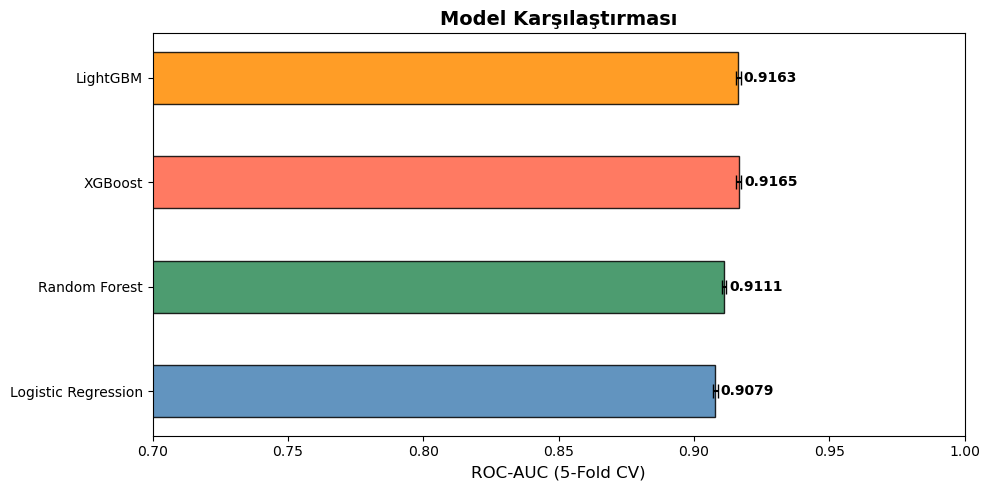

In [19]:
# Sonuçları görselleştir
fig, ax = plt.subplots(figsize=(10, 5))

names = list(results.keys())
means = [results[n].mean() for n in names]
stds  = [results[n].std()  for n in names]
colors = ['steelblue', 'seagreen', 'tomato', 'darkorange']

bars = ax.barh(names, means, xerr=stds, color=colors, alpha=0.85,
               edgecolor='black', height=0.5, capsize=5)
ax.set_xlabel('ROC-AUC (5-Fold CV)', fontsize=12)
ax.set_title('Model Karşılaştırması', fontsize=14, fontweight='bold')
ax.set_xlim(0.7, 1.0)
for bar, mean in zip(bars, means):
    ax.text(mean + 0.002, bar.get_y() + bar.get_height()/2,
            f'{mean:.4f}', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

## Final Model: LightGBM + Out-of-Fold Predictions

**Out-of-Fold (OOF) nedir?**  
Her fold'u train ederken, o fold'un validation kısmına tahmin yaparız ve bu tahminleri birleştiririz. Böylece tüm train verisi için "hiç görülmeden yapılmış" tahminler elde ederiz — bu da leaderboard skorunu daha iyi tahmin eder.

**Neden OOF?** Sadece `cross_val_score` yerine OOF kullanmak, ensemble/stacking için de temel oluşturur.

In [20]:
from sklearn.metrics import roc_auc_score

X_arr = X.values
y_arr = y.values
X_test_arr = X_test_final.values

N_FOLDS = 5
cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

oof_preds   = np.zeros(len(X_arr))
test_preds  = np.zeros(len(X_test_arr))
fold_scores = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_arr, y_arr)):
    X_tr, X_val = X_arr[train_idx], X_arr[val_idx]
    y_tr, y_val = y_arr[train_idx], y_arr[val_idx]

    model = LGBMClassifier(
        n_estimators=1000,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_samples=20,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb_early_stop := __import__('lightgbm').early_stopping(50, verbose=False),
                   __import__('lightgbm').log_evaluation(period=-1)]
    )

    val_pred = model.predict_proba(X_val)[:, 1]
    oof_preds[val_idx] = val_pred

    test_pred = model.predict_proba(X_test_arr)[:, 1]
    test_preds += test_pred / N_FOLDS

    score = roc_auc_score(y_val, val_pred)
    fold_scores.append(score)
    print(f"Fold {fold+1}  AUC: {score:.4f}  (best iter: {model.best_iteration_})")

oof_score = roc_auc_score(y_arr, oof_preds)
print(f"\nOOF AUC: {oof_score:.4f}")
print(f"Mean Fold AUC: {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}")

Fold 1  AUC: 0.9161  (best iter: 751)
Fold 2  AUC: 0.9172  (best iter: 782)
Fold 3  AUC: 0.9164  (best iter: 656)
Fold 4  AUC: 0.9176  (best iter: 826)
Fold 5  AUC: 0.9148  (best iter: 619)

OOF AUC: 0.9164
Mean Fold AUC: 0.9164 ± 0.0010


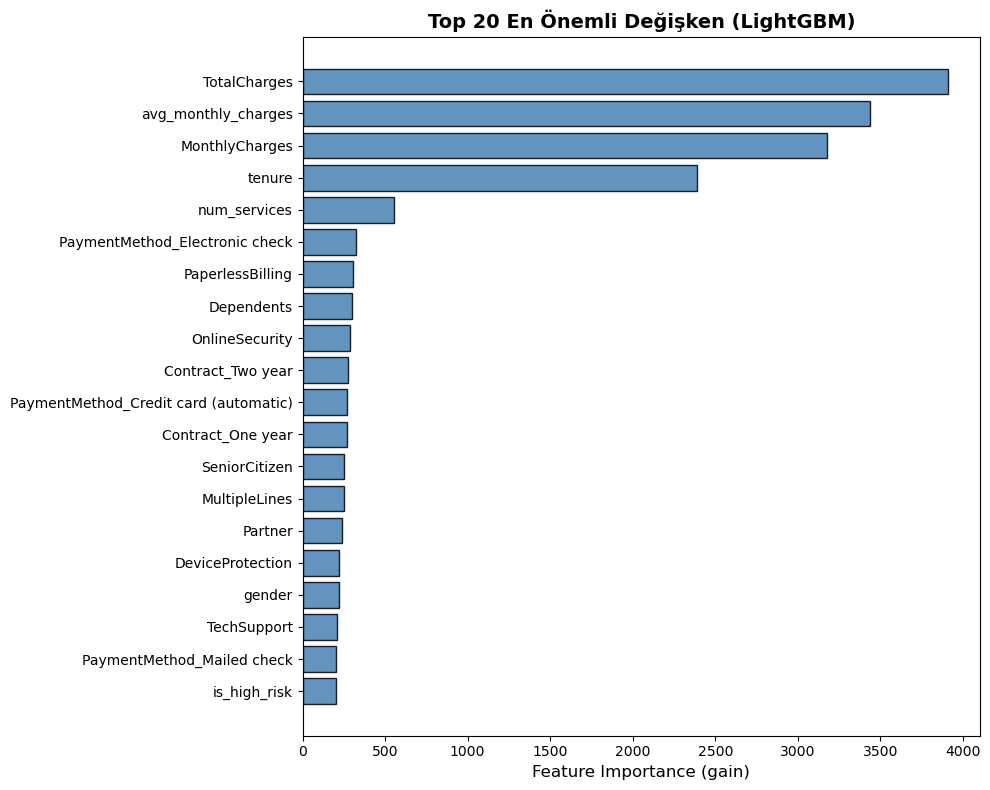

In [21]:
# Feature Importance — hangi değişkenler modele en çok katkı sağlıyor?
feat_imp = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
plt.barh(feat_imp['feature'][::-1], feat_imp['importance'][::-1],
         color='steelblue', edgecolor='black', alpha=0.85)
plt.xlabel('Feature Importance (gain)', fontsize=12)
plt.title('Top 20 En Önemli Değişken (LightGBM)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Submission

Kaggle'a göndermek için `sample_submission.csv` formatını kontrol edelim ve `test_preds` (her test satırı için churn olasılığı) ile dosyayı oluşturalım.

Kaggle bu yarışmada genellikle `Churn` sütununda **olasılık (probability)** ister — binary 0/1 değil. Bu yüzden `predict_proba`'yı kullandık.

In [22]:
import os

# Submission dosyasını oluştur
submission = pd.DataFrame({
    'id': test_df['id'],
    'Churn': test_preds
})

print("Submission önizleme:")
print(submission.head(10))
print(f"\nShape: {submission.shape}")
print(f"Churn olasılığı - min: {test_preds.min():.4f}, max: {test_preds.max():.4f}, mean: {test_preds.mean():.4f}")

# Kaydet
output_dir = '../submissions'
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, 'submission_lgbm_oof.csv')
submission.to_csv(output_path, index=False)
print(f"\nDosya kaydedildi: {output_path}")

Submission önizleme:
       id     Churn
0  594194  0.070228
1  594195  0.000414
2  594196  0.104881
3  594197  0.003533
4  594198  0.473658
5  594199  0.178078
6  594200  0.889041
7  594201  0.002451
8  594202  0.029069
9  594203  0.300879

Shape: (254655, 2)
Churn olasılığı - min: 0.0001, max: 0.9894, mean: 0.2180

Dosya kaydedildi: ../submissions/submission_lgbm_oof.csv


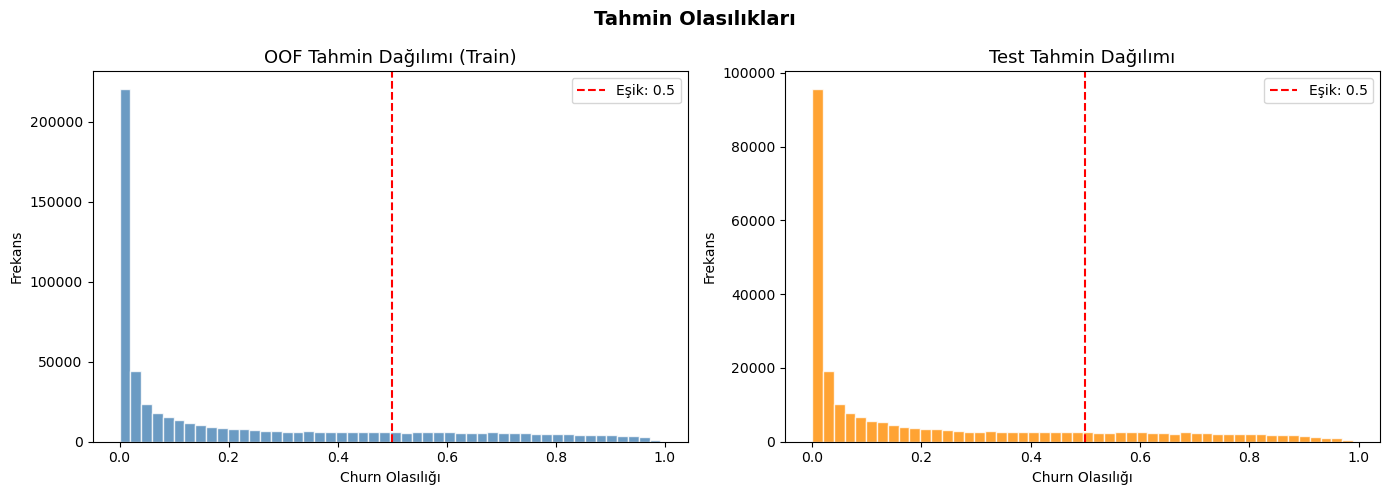


Final OOF AUC: 0.9164
Tahmini LB skoru: ~0.9164

Submission hazır: submissions/submission_lgbm_oof.csv


In [23]:
# OOF tahminlerinin dağılımı — modelin ne kadar emin olduğunu görürüz
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# OOF dağılımı
axes[0].hist(oof_preds, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('OOF Tahmin Dağılımı (Train)', fontsize=13)
axes[0].set_xlabel('Churn Olasılığı')
axes[0].set_ylabel('Frekans')
axes[0].axvline(0.5, color='red', linestyle='--', label='Eşik: 0.5')
axes[0].legend()

# Test tahmin dağılımı
axes[1].hist(test_preds, bins=50, color='darkorange', edgecolor='white', alpha=0.8)
axes[1].set_title('Test Tahmin Dağılımı', fontsize=13)
axes[1].set_xlabel('Churn Olasılığı')
axes[1].set_ylabel('Frekans')
axes[1].axvline(0.5, color='red', linestyle='--', label='Eşik: 0.5')
axes[1].legend()

plt.suptitle('Tahmin Olasılıkları', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nFinal OOF AUC: {oof_score:.4f}")
print(f"Tahmini LB skoru: ~{oof_score:.4f}")
print(f"\nSubmission hazır: submissions/submission_lgbm_oof.csv")

# Score İyileştirme

**Mevcut skor:** 0.91388  
**Hedef:** Top 500 (~0.923+)

**Plan:**
1. Gelişmiş Feature Engineering (interaction features)
2. Optuna ile LightGBM Hyperparameter Tuning
3. Multi-model Ensemble (LGBM + XGBoost + CatBoost)
4. Final Submission

## Step 1: Gelişmiş Feature Engineering

**Interaction features nedir?** İki değişkeni çarparak veya bölerek elde edilen yeni değişkenler.  
Örneğin `tenure × MonthlyCharges` — hem uzun süredir müşteri hem de çok ödeyenler farklı davranıyor.

**Target encoding nedir?** Kategorik bir değişkenin her kategorisi için o kategorinin ortalama churn oranını hesaplıyoruz. Örneğin `Contract=Month-to-month` → %42 churn oranı varsa, bu değişken 0.42 değerini alır. Modelin kategorik ilişkileri daha iyi yakalamasını sağlar.

In [ ]:
def advanced_features(df, train_ref=None, target_enc_map=None, fit=True):
    """
    fit=True  → train üzerinde target encoding öğrenir
    fit=False → öğrenilen map'i test'e uygular (data leakage önlemi)
    """
    df = df.copy()

    # === Interaction Features ===

    # 1. Aylık yük: ne kadar süredir müşteri × aylık ücret
    df['tenure_x_monthly'] = df['tenure'] * df['MonthlyCharges']

    # 2. Ücret yoğunluğu: aylık ücretin toplam'a oranı (TotalCharges zaten dolduruldu)
    df['charge_ratio'] = df['MonthlyCharges'] / (df['TotalCharges'] + 1)

    # 3. Log dönüşümü: sağa çarpık dağılımları normalleştirir
    df['log_TotalCharges']   = np.log1p(df['TotalCharges'])
    df['log_MonthlyCharges'] = np.log1p(df['MonthlyCharges'])
    df['log_tenure']         = np.log1p(df['tenure'])

    # 4. Contract + Senior kombinasyonu (yüksek risk segment)
    df['senior_month_to_month'] = (
        (df['SeniorCitizen'] == 1) & (df['Contract'] == 'Month-to-month')
    ).astype(int)

    # 5. Hizmet yoğunluğu = num_services / (tenure + 1)
    df['service_density'] = df['num_services'] / (df['tenure'] + 1)

    # 6. MonthlyCharges bin
    df['monthly_bin'] = pd.cut(df['MonthlyCharges'],
                                bins=[0, 35, 65, 85, 120],
                                labels=[0, 1, 2, 3]).astype(float)

    # === Target Encoding (sadece train'den öğren, test'e uygula) ===
    # Burada Contract, PaymentMethod, InternetService için
    te_cols = ['Contract', 'PaymentMethod', 'InternetService']

    if fit:
        target_enc_map = {}
        for col in te_cols:
            if col in df.columns and train_ref is not None:
                mean_map = train_ref.groupby(col)['Churn'].apply(
                    lambda x: (x == 'Yes').mean()
                )
                target_enc_map[col] = mean_map
                df[f'{col}_te'] = df[col].map(mean_map)
    else:
        for col in te_cols:
            if col in df.columns and target_enc_map is not None:
                df[f'{col}_te'] = df[col].map(target_enc_map.get(col, {}))

    return df, target_enc_map

# Train üzerinde fit et
train_fe2, te_map = advanced_features(train_df, train_ref=train_df, fit=True)
# Test'e aynı map ile uygula (leakage yok)
test_fe2, _       = advanced_features(test_df, target_enc_map=te_map, fit=False)

print("Yeni feature'lar:")
new_fe2_cols = ['tenure_x_monthly', 'charge_ratio', 'log_TotalCharges',
                'senior_month_to_month', 'service_density', 'monthly_bin',
                'Contract_te', 'PaymentMethod_te', 'InternetService_te']
print(train_fe2[new_fe2_cols].head())

In [ ]:
# Yeni feature'lar eklenmiş veriyi encode et
train_enc2 = encode_df(train_fe2)
test_enc2  = encode_df(test_fe2)

train_enc2['Churn'] = (train_enc2['Churn'] == 'Yes').astype(int)

drop_cols2 = ['id', 'Churn']
feature_cols2 = [c for c in train_enc2.columns if c not in drop_cols2]

for col in feature_cols2:
    if col not in test_enc2.columns:
        test_enc2[col] = 0

X2          = train_enc2[feature_cols2]
y2          = train_enc2['Churn']
X2_test     = test_enc2[feature_cols2]

print(f"Toplam feature sayısı: {len(feature_cols2)}  (önceki: {len(feature_cols)})")
print(f"X2 shape: {X2.shape}")

## Step 2: Optuna ile Hyperparameter Tuning

**Optuna nedir?** Bayesian optimizasyon tabanlı hyperparameter arama kütüphanesi.  
Grid search (her kombinasyonu dene) yerine akıllıca arama yapar — önceki denemelerden öğrenerek daha umut verici parametrelere yönelir.

**`n_trials=50`** — 50 farklı parametre kombinasyonu dener. Daha fazla = daha iyi sonuç ama daha uzun süre.

**Pruning:** Kötü giden denemeleri erken keser (MedianPruner), böylece zaman kazanılır.

In [ ]:
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

X2_arr   = X2.values
y2_arr   = y2.values
cv_optuna = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)  # 3-fold → hızlı

def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 300, 1500),
        'max_depth':         trial.suggest_int('max_depth', 3, 9),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 20, 200),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1,
    }

    scores = []
    for tr_idx, val_idx in cv_optuna.split(X2_arr, y2_arr):
        X_tr, X_val = X2_arr[tr_idx], X2_arr[val_idx]
        y_tr, y_val = y2_arr[tr_idx], y2_arr[val_idx]

        m = LGBMClassifier(**params)
        m.fit(X_tr, y_tr,
              eval_set=[(X_val, y_val)],
              callbacks=[
                  __import__('lightgbm').early_stopping(30, verbose=False),
                  __import__('lightgbm').log_evaluation(period=-1)
              ])
        scores.append(roc_auc_score(y_val, m.predict_proba(X_val)[:, 1]))

    return np.mean(scores)

study = optuna.create_study(direction='maximize',
                             sampler=TPESampler(seed=42))
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nEn iyi AUC: {study.best_value:.4f}")
print(f"En iyi parametreler:\n{study.best_params}")

## Step 3: Ensemble — LGBM + XGBoost + CatBoost

**Neden ensemble?** Farklı modeller farklı pattern'leri öğrenir. Tahminlerini ortalaladığında birbirinin hatalarını telafi ederler → tek modelden daha iyi skor.

**Ağırlıklı ortalama:** Her modelin OOF AUC'una göre ağırlık veririz — daha iyi model daha fazla söz hakkı alır.

In [ ]:
from catboost import CatBoostClassifier

N_FOLDS = 5
cv5 = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

X2_test_arr = X2_test.values

# Tuned LGBM parametreleri (Optuna'dan)
best_lgbm_params = {**study.best_params, 'random_state': 42, 'n_jobs': -1, 'verbose': -1}

model_configs = {
    'lgbm': LGBMClassifier(**best_lgbm_params),
    'xgb':  XGBClassifier(
                n_estimators=1000, max_depth=6, learning_rate=0.05,
                subsample=0.8, colsample_bytree=0.8,
                use_label_encoder=False, eval_metric='auc',
                random_state=42, n_jobs=-1
            ),
    'cat':  CatBoostClassifier(
                iterations=1000, depth=6, learning_rate=0.05,
                eval_metric='AUC', random_seed=42,
                verbose=0, thread_count=-1
            ),
}

oof_store  = {}
test_store = {}

for model_name, base_model in model_configs.items():
    print(f"\n{'='*45}")
    print(f"Model: {model_name.upper()}")
    print(f"{'='*45}")

    oof_p  = np.zeros(len(X2_arr))
    test_p = np.zeros(len(X2_test_arr))
    fold_aucs = []

    for fold, (tr_idx, val_idx) in enumerate(cv5.split(X2_arr, y2_arr)):
        X_tr, X_val = X2_arr[tr_idx], X2_arr[val_idx]
        y_tr, y_val = y2_arr[tr_idx], y2_arr[val_idx]

        import copy
        m = copy.deepcopy(base_model)

        if model_name == 'lgbm':
            m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
                  callbacks=[
                      __import__('lightgbm').early_stopping(50, verbose=False),
                      __import__('lightgbm').log_evaluation(period=-1)
                  ])
        elif model_name == 'xgb':
            m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
                  verbose=False)
        elif model_name == 'cat':
            m.fit(X_tr, y_tr, eval_set=(X_val, y_val),
                  use_best_model=True, verbose=False)

        val_pred  = m.predict_proba(X_val)[:, 1]
        test_pred = m.predict_proba(X2_test_arr)[:, 1]

        oof_p[val_idx] = val_pred
        test_p += test_pred / N_FOLDS

        auc = roc_auc_score(y_val, val_pred)
        fold_aucs.append(auc)
        print(f"  Fold {fold+1}  AUC: {auc:.4f}")

    oof_auc = roc_auc_score(y2_arr, oof_p)
    print(f"  OOF AUC: {oof_auc:.4f}")
    oof_store[model_name]  = (oof_p, oof_auc)
    test_store[model_name] = test_p

In [ ]:
# Ağırlıklı ensemble: OOF AUC'una göre ağırlık
print("Model OOF AUC'ları:")
weights = {}
for name, (oof_p, oof_auc) in oof_store.items():
    print(f"  {name.upper():6s}: {oof_auc:.4f}")
    weights[name] = oof_auc

total_weight = sum(weights.values())
weights = {k: v / total_weight for k, v in weights.items()}
print(f"\nNormalize edilmiş ağırlıklar: {weights}")

# Ensemble OOF
ensemble_oof = sum(oof_store[name][0] * weights[name] for name in oof_store)
ensemble_test = sum(test_store[name] * weights[name] for name in test_store)

ensemble_auc = roc_auc_score(y2_arr, ensemble_oof)
print(f"\nEnsemble OOF AUC: {ensemble_auc:.4f}")
print(f"İyileşme (baseline'dan): +{ensemble_auc - 0.91388:.4f}")

## Step 4: Final Submission

In [ ]:
submission_v2 = pd.DataFrame({
    'id':    test_df['id'],
    'Churn': ensemble_test
})

output_path_v2 = '../submissions/submission_ensemble_v2.csv'
submission_v2.to_csv(output_path_v2, index=False)

print("=" * 50)
print("FINAL SUBMISSION")
print("=" * 50)
print(submission_v2.head(10))
print(f"\nShape: {submission_v2.shape}")
print(f"Churn prob — min: {ensemble_test.min():.4f}  max: {ensemble_test.max():.4f}  mean: {ensemble_test.mean():.4f}")
print(f"\nOOF AUC: {ensemble_auc:.4f}")
print(f"Kaydedildi: {output_path_v2}")

# Görselleştir
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(ensemble_oof, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('OOF Tahmin Dağılımı', fontsize=12)
axes[0].axvline(0.5, color='red', linestyle='--', label='0.5')
axes[0].legend()

axes[1].hist(ensemble_test, bins=60, color='darkorange', edgecolor='white', alpha=0.8)
axes[1].set_title('Test Tahmin Dağılımı', fontsize=12)
axes[1].axvline(0.5, color='red', linestyle='--', label='0.5')
axes[1].legend()

plt.suptitle(f'Ensemble Tahminleri  |  OOF AUC: {ensemble_auc:.4f}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Score İyileştirme v2

**Sorun analizi:** 0.91388 → 0.91401 (sadece +0.00013) — neredeyse hiç iyileşme yok.

**Kök sebepler:**
- Target encoding tüm train üzerinden hesaplandı → **data leakage** (model eğitim verisindeki target bilgisini görüyor, test'te bu avantaj yok)
- Yeni featurelar gürültü ekliyor olabilir

**Çözümler (etki sırasıyla):**
1. **Orijinal Telco veri seti** → Playground Series orijinal veriden üretildi, ekleyince model çok daha fazla örnek görür
2. **K-Fold Target Encoding** → her fold'da diğer fold'ların ortalamasını kullan, leakage yok
3. **Pseudo-labeling** → yüksek güvenli test tahminleri train'e eklenir

## Step A: Orijinal Telco Veri Setini Ekle

Kaggle Playground Series yarışmaları gerçek bir veri setinden sentetik veri üretir.  
Bu yarışmanın orijinali: **IBM Telco Customer Churn** (7043 satır).

Orijinal veriyi `../data/` klasörüne `WA_Fn-UseC_-Telco-Customer-Churn.csv` olarak indirip ekliyoruz.  
**Kaggle'dan indirme:** https://www.kaggle.com/datasets/blastchar/telco-customer-churn

Orijinal veri yoksa bu hücre atlanır, geri kalanlar çalışmaya devam eder.